In [170]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image features
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import gabor

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.impute import SimpleImputer

try:
    import xgboost as xgb
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print(" XGBoost not installed. Install with: pip install xgboost")


In [171]:
# -----------------------------
# 2. Dataset configuration
# -----------------------------
DATASET_PATH = "dataset"
classes = ["Normal", "stone"]
label_map = {label: idx for idx, label in enumerate(classes)}
IMG_SIZE = (256, 256)

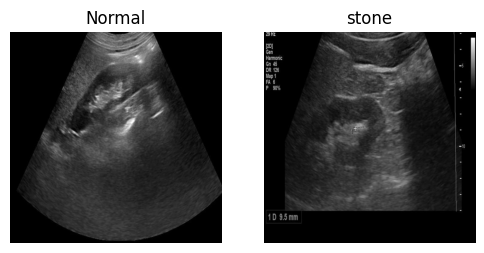

In [172]:
plt.figure(figsize=(6,3))

for i, cls in enumerate(classes):
    folder = os.path.join(DATASET_PATH, cls)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(1,2,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.show()


In [173]:
# -----------------------------
# 3. Load and preprocess images
# -----------------------------
def load_and_preprocess_images(dataset_path, classes, img_size=(256,256)):
    images, labels = [], []
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            # Grayscale → Resize → Crop → Median Filter → Normalize
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_resized = cv2.resize(img_gray, img_size)
            img_masked = img_resized[10:-10, 10:-10]
            img_filtered = cv2.medianBlur(img_masked, 5)
            img_normalized = img_filtered / 255.0
            images.append(img_normalized)
            labels.append(label_map[class_name])
    return np.array(images), np.array(labels)

print("Loading images...")
images, labels = load_and_preprocess_images(DATASET_PATH, classes, IMG_SIZE)
print(f"Loaded {len(images)} images: {np.sum(labels==0)} Normal, {np.sum(labels==1)} Stone")


Loading images...
Loaded 2000 images: 1000 Normal, 1000 Stone


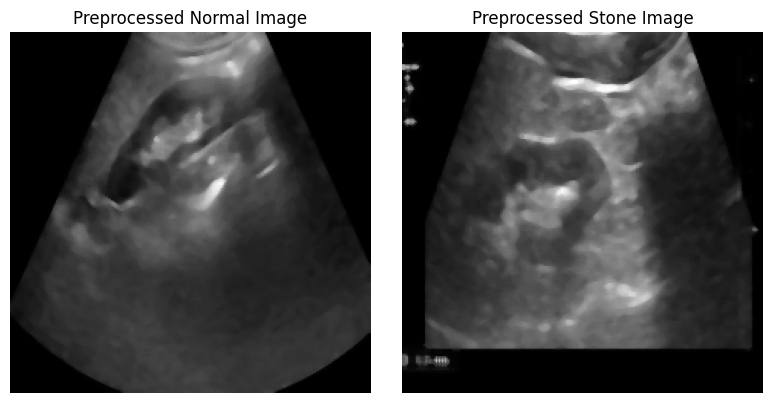

In [174]:
# -----------------------------
# Visualize image after preprocessing
# -----------------------------
plt.figure(figsize=(8,4))

# Show one Normal and one Stone image after preprocessing
normal_idx = np.where(labels == 0)[0][0]
stone_idx  = np.where(labels == 1)[0][0]

plt.subplot(1, 2, 1)
plt.imshow(images[normal_idx], cmap='gray')
plt.title("Preprocessed Normal Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(images[stone_idx], cmap='gray')
plt.title("Preprocessed Stone Image")
plt.axis('off')

plt.tight_layout()
plt.show()

In [175]:
# -----------------------------
# 4. Feature extraction (GLCM + Gabor entropy)
# -----------------------------
def extract_features(images):
    features_list = []
    for img in images:
        # Gabor entropy
        gabor_real, _ = gabor(img, frequency=0.6)
        entropy_val = -np.sum(gabor_real * np.log2(gabor_real + 1e-10))

        # GLCM features
        glcm_features = []
        distances = [1,3,5]
        angles = [0, np.pi/4, np.pi/2, np.pi]
        img_uint8 = (img*255).astype(np.uint8)
        for d in distances:
            for a in angles:
                glcm = graycomatrix(img_uint8, distances=[d], angles=[a], levels=256, symmetric=True, normed=True)
                glcm_features.extend([
                    graycoprops(glcm, 'energy')[0,0],
                    graycoprops(glcm, 'correlation')[0,0],
                    graycoprops(glcm, 'contrast')[0,0],
                    graycoprops(glcm, 'homogeneity')[0,0],
                    graycoprops(glcm, 'dissimilarity')[0,0]
                ])
        features_list.append([entropy_val] + glcm_features)
    return np.array(features_list)

print("Extracting features...")
features = extract_features(images)
print("Features shape:", features.shape)

Extracting features...


C:\Users\Somaya Ahmad\AppData\Local\Temp\ipykernel_19632\344863322.py:9: RuntimeWarning: invalid value encountered in log2
  entropy_val = -np.sum(gabor_real * np.log2(gabor_real + 1e-10))


Features shape: (2000, 61)


In [176]:
# -----------------------------
#  Handle NaNs and remove duplicates
# -----------------------------

from sklearn.impute import SimpleImputer
# Replace fully empty columns with 0 first
features = np.where(np.isnan(features), 0, features)

#  Handle NaNs first
imputer = SimpleImputer(strategy='mean')
features = imputer.fit_transform(features)  # Fill NaNs with column mean

# 2. Make proper column names
num_features = features.shape[1]  # Should be 61
feature_names = ['Gabor_entropy'] + [f'GLCM_{i+1}' for i in range(num_features-1)]

# 3. Create DataFrame with feature names
df = pd.DataFrame(features, columns=feature_names)
df['Label'] = labels
df['Class'] = df['Label'].map({0:'Normal', 1:'Stone'})

# 4. Remove duplicate rows if needed
df = df.drop_duplicates().reset_index(drop=True)

# 5. Split X and y
X = df.drop(['Label', 'Class'], axis=1).values
y = df['Label'].values

# 6. Check
print("Shape after removing duplicates:", X.shape)
print("Columns:", df.columns)
print("Number of duplicate rows:", df.duplicated().sum())
print("Null values:\n", df.isnull().sum())

Shape after removing duplicates: (1842, 61)
Columns: Index(['Gabor_entropy', 'GLCM_1', 'GLCM_2', 'GLCM_3', 'GLCM_4', 'GLCM_5',
       'GLCM_6', 'GLCM_7', 'GLCM_8', 'GLCM_9', 'GLCM_10', 'GLCM_11', 'GLCM_12',
       'GLCM_13', 'GLCM_14', 'GLCM_15', 'GLCM_16', 'GLCM_17', 'GLCM_18',
       'GLCM_19', 'GLCM_20', 'GLCM_21', 'GLCM_22', 'GLCM_23', 'GLCM_24',
       'GLCM_25', 'GLCM_26', 'GLCM_27', 'GLCM_28', 'GLCM_29', 'GLCM_30',
       'GLCM_31', 'GLCM_32', 'GLCM_33', 'GLCM_34', 'GLCM_35', 'GLCM_36',
       'GLCM_37', 'GLCM_38', 'GLCM_39', 'GLCM_40', 'GLCM_41', 'GLCM_42',
       'GLCM_43', 'GLCM_44', 'GLCM_45', 'GLCM_46', 'GLCM_47', 'GLCM_48',
       'GLCM_49', 'GLCM_50', 'GLCM_51', 'GLCM_52', 'GLCM_53', 'GLCM_54',
       'GLCM_55', 'GLCM_56', 'GLCM_57', 'GLCM_58', 'GLCM_59', 'GLCM_60',
       'Label', 'Class'],
      dtype='object')
Number of duplicate rows: 0
Null values:
 Gabor_entropy    0
GLCM_1           0
GLCM_2           0
GLCM_3           0
GLCM_4           0
                ..
GLCM_

In [ ]:
# 5. Visualize features as a table
print("Feature table:")
print(df.head())  # Display first 5 rows

Feature table:
   Gabor_entropy    GLCM_1    GLCM_2     GLCM_3    GLCM_4    GLCM_5    GLCM_6  \
0            0.0  0.246504  0.993735  14.837306  0.636452  1.617797  0.243713   
1            0.0  0.272004  0.994186  25.208132  0.644288  1.763018  0.267382   
2            0.0  0.269964  0.991376  31.173657  0.638872  1.886206  0.265576   
3            0.0  0.296479  0.992568  47.879354  0.601748  2.463235  0.292277   
4            0.0  0.268853  0.995993  55.236423  0.547036  2.907032  0.264711   

     GLCM_7      GLCM_8    GLCM_9  ...     GLCM_53   GLCM_54    GLCM_55  \
0  0.985768   33.622363  0.565625  ...  169.772709  0.379096   6.517151   
1  0.985652   62.167623  0.569082  ...  425.083021  0.363454   9.570145   
2  0.982618   62.802698  0.543825  ...  409.322364  0.338731  10.775039   
3  0.985054   96.214830  0.503244  ...  495.294336  0.329620  12.383264   
4  0.991959  110.645867  0.472464  ...  847.085553  0.315921  16.097696   

    GLCM_56   GLCM_57     GLCM_58   GLCM_59    

In [ ]:
# -----------------------------
# Outlier detection and handling (IQR + capping)
# -----------------------------

# Assume X is your feature matrix (n_samples x n_features)

# Calculate IQR for each feature column
Q1 = np.percentile(X, 25, axis=0)
Q3 = np.percentile(X, 75, axis=0)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#  Count total outlier values
outlier_mask = (X < lower_bound) | (X > upper_bound)
outlier_count = np.sum(outlier_mask)
print("Total outlier values detected:", outlier_count)

#  Cap/floor outliers column-wise
X_capped = np.copy(X)
for col in range(X.shape[1]):
    # Replace values below lower bound
    X_capped[:, col] = np.where(X[:, col] < lower_bound[col], lower_bound[col], X_capped[:, col])
    # Replace values above upper bound
    X_capped[:, col] = np.where(X_capped[:, col] > upper_bound[col], upper_bound[col], X_capped[:, col])

#  Visualize before and after using pandas DataFrame
feature_names = ['Gabor_entropy'] + [f'GLCM_{i+1}' for i in range(X.shape[1]-1)]

df_before = pd.DataFrame(X, columns=feature_names)
df_after = pd.DataFrame(X_capped, columns=feature_names)

print("\nFeature values before capping outliers:")
print(df_before.head())

print("\nFeature values after capping outliers:")
print(df_after.head())

Total outlier values detected: 2502

Feature values before capping outliers:
   Gabor_entropy    GLCM_1    GLCM_2     GLCM_3    GLCM_4    GLCM_5    GLCM_6  \
0            0.0  0.246504  0.993735  14.837306  0.636452  1.617797  0.243713   
1            0.0  0.272004  0.994186  25.208132  0.644288  1.763018  0.267382   
2            0.0  0.269964  0.991376  31.173657  0.638872  1.886206  0.265576   
3            0.0  0.296479  0.992568  47.879354  0.601748  2.463235  0.292277   
4            0.0  0.268853  0.995993  55.236423  0.547036  2.907032  0.264711   

     GLCM_7      GLCM_8    GLCM_9  ...   GLCM_51   GLCM_52     GLCM_53  \
0  0.985768   33.622363  0.565625  ...  0.232456  0.927459  169.772709   
1  0.985652   62.167623  0.569082  ...  0.247182  0.901691  425.083021   
2  0.982618   62.802698  0.543825  ...  0.246561  0.886447  409.322364   
3  0.985054   96.214830  0.503244  ...  0.272774  0.922775  495.294336   
4  0.991959  110.645867  0.472464  ...  0.247302  0.938082  847.08

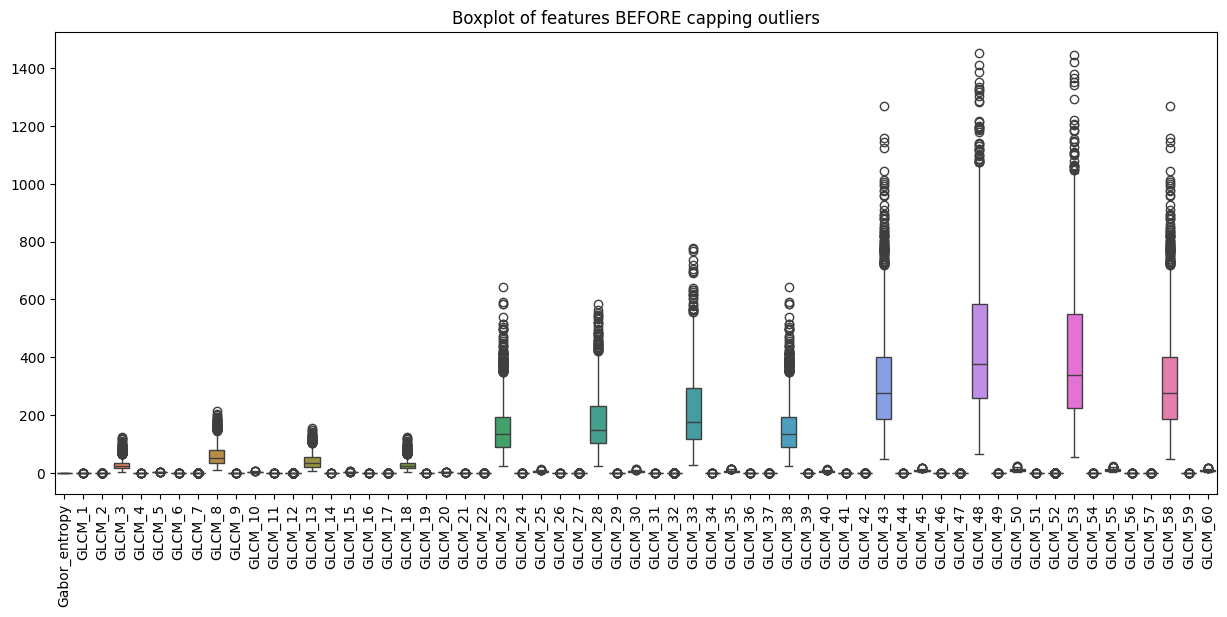

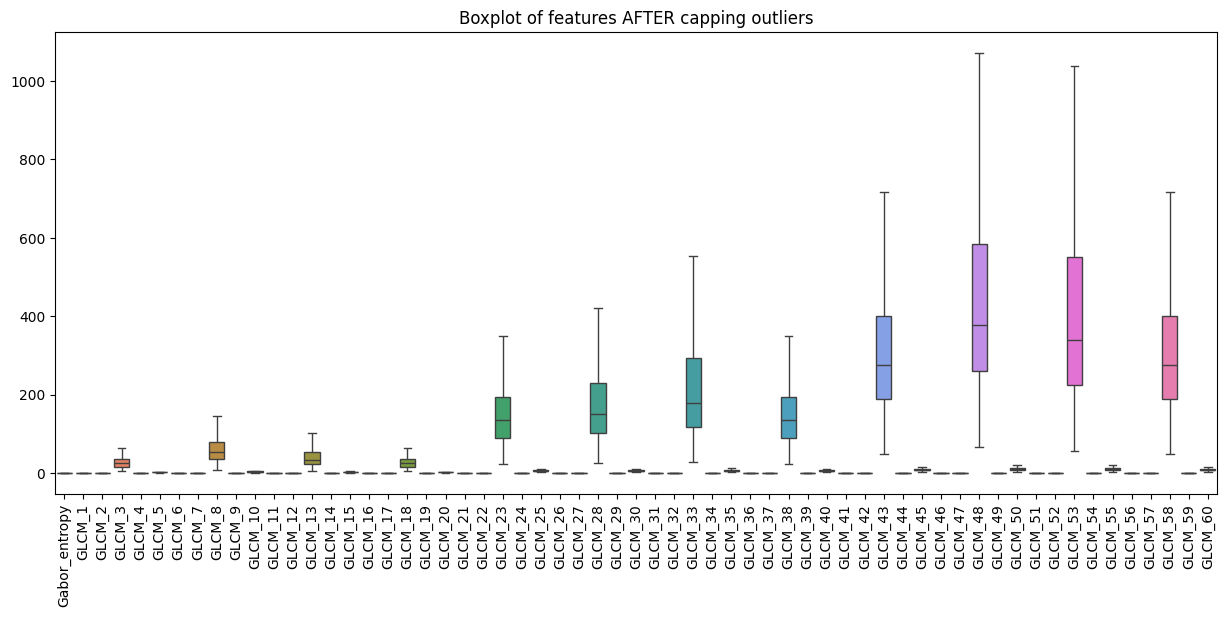

In [ ]:
# -----------------------------
# Boxplot visualization
# -----------------------------

# Before capping
plt.figure(figsize=(15,6))
sns.boxplot(data=df_before)
plt.xticks(rotation=90)
plt.title("Boxplot of features BEFORE capping outliers")
plt.show()

#  After capping
plt.figure(figsize=(15,6))
sns.boxplot(data=df_after)
plt.xticks(rotation=90)
plt.title("Boxplot of features AFTER capping outliers")
plt.show()

In [ ]:
# -----------------------------
# Split data: train/val/test (70/15/15)
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X_capped, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

Train: (1289, 61) Validation: (276, 61) Test: (277, 61)


In [ ]:
# ============================================
# 7. Train and Compare Multiple Classifiers
# ============================================

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Optional XGBoost
try:
    import xgboost as xgb
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False


print("\n" + "=" * 70)
print("BASELINE CLASSIFIER COMPARISON (ALL FEATURES)")
print("=" * 70 + "\n")

results_baseline = {}
classifiers = {}

# ------------------------------------------------
# SVM Classifier
# ------------------------------------------------
print("Training SVM Classifier...")
classifiers['SVM'] = SVC(kernel='linear', probability=True, random_state=42)
classifiers['SVM'].fit(X_train, y_train)

y_pred_svm = classifiers['SVM'].predict(X_test)

results_baseline['SVM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1-Score': f1_score(y_test, y_pred_svm)
}

print(f"  ✓ SVM trained. Test Accuracy: {results_baseline['SVM']['Accuracy']:.4f}\n")


# ------------------------------------------------
# Random Forest Classifier
# ------------------------------------------------
print("Training Random Forest Classifier...")
classifiers['RandomForest'] = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
classifiers['RandomForest'].fit(X_train, y_train)

y_pred_rf = classifiers['RandomForest'].predict(X_test)

results_baseline['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf)
}

print(f"  ✓ Random Forest trained. Test Accuracy: {results_baseline['Random Forest']['Accuracy']:.4f}\n")


# ------------------------------------------------
# XGBoost Classifier (Optional)
# ------------------------------------------------
if HAS_XGBOOST:
    print("Training XGBoost Classifier...")
    classifiers['XGBoost'] = xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )

    classifiers['XGBoost'].fit(X_train, y_train)
    y_pred_xgb = classifiers['XGBoost'].predict(X_test)

    results_baseline['XGBoost'] = {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb),
        'F1-Score': f1_score(y_test, y_pred_xgb)
    }

    print(f" XGBoost trained. Test Accuracy: {results_baseline['XGBoost']['Accuracy']:.4f}\n")
else:
    print(" XGBoost not available. Skipping XGBoost.\n")


# ------------------------------------------------
# Results Summary
# ------------------------------------------------
results_baseline_df = pd.DataFrame(results_baseline).T
results_baseline_df = results_baseline_df.sort_values(by='Accuracy', ascending=False)

print("=" * 70)
print("CLASSIFIER PERFORMANCE SUMMARY")
print("=" * 70)
print(results_baseline_df.to_string(float_format="%.4f"))

# Best classifier
best_classifier = results_baseline_df.index[0]
best_accuracy = results_baseline_df.iloc[0]['Accuracy']

print("\n" + "=" * 70)
print(f"Best Classifier: {best_classifier} with {best_accuracy:.4f} accuracy")
print("=" * 70 + "\n")



BASELINE CLASSIFIER COMPARISON (ALL FEATURES)

Training SVM Classifier...
  ✓ SVM trained. Test Accuracy: 0.9422

Training Random Forest Classifier...
  ✓ Random Forest trained. Test Accuracy: 0.9350

Training XGBoost Classifier...
 XGBoost trained. Test Accuracy: 0.9495

CLASSIFIER PERFORMANCE SUMMARY
               Accuracy  Precision  Recall  F1-Score
XGBoost          0.9495     0.9449  0.9449    0.9449
SVM              0.9422     0.9664  0.9055    0.9350
Random Forest    0.9350     0.9160  0.9449    0.9302

Best Classifier: XGBoost with 0.9495 accuracy



# 7. Feature Selection

**Why Feature Selection?**
- Reduces dimensionality and improves model efficiency
- Removes irrelevant/redundant features that add noise
- Enhances model interpretability
- Reduces overfitting and improves generalization
- Decreases training and inference time

In [ ]:
from sklearn.feature_selection import mutual_info_classif, f_classif

# ============================================
# Method 1: Information Gain (Entropy Reduction)
# ============================================
# Information Gain measures how much knowing a feature reduces uncertainty about the class label
# IG = Information entropy before split - weighted entropy after split
# Higher IG = feature provides more information for classification

info_gain_scores = mutual_info_classif(X_train, y_train, random_state=42)
info_gain_df = pd.DataFrame({
    'Feature': feature_names,
    'Information Gain': info_gain_scores
}).sort_values('Information Gain', ascending=False)

print("=" * 50)
print("Method 1: Information Gain Scores")
print("=" * 50)
print(info_gain_df.to_string())
print("\n")

Method 1: Information Gain Scores
          Feature  Information Gain
51        GLCM_51          0.345890
41        GLCM_41          0.330535
56        GLCM_56          0.330535
46        GLCM_46          0.329428
21        GLCM_21          0.323647
36        GLCM_36          0.323647
31        GLCM_31          0.318112
26        GLCM_26          0.309061
16        GLCM_16          0.308371
1          GLCM_1          0.308371
11        GLCM_11          0.307957
6          GLCM_6          0.306591
59        GLCM_59          0.246149
44        GLCM_44          0.246149
24        GLCM_24          0.244132
39        GLCM_39          0.244132
49        GLCM_49          0.242243
54        GLCM_54          0.234685
29        GLCM_29          0.233733
34        GLCM_34          0.216665
4          GLCM_4          0.203120
19        GLCM_19          0.203120
14        GLCM_14          0.201828
9          GLCM_9          0.187931
2          GLCM_2          0.174043
17        GLCM_17          0.1

In [ ]:
# ============================================
# Method 2: Fisher's Test (ANOVA F-Test)
# ============================================
# Fisher's test (F-Test) measures linear dependency between features and target
# It computes the variance ratio: variance between classes / variance within classes
# Higher F-score = stronger linear relationship with target class
# Based on statistical testing of mean differences between Normal and Stone classes

fisher_scores = f_classif(X_train, y_train)[0]
fisher_df = pd.DataFrame({
    'Feature': feature_names,
    'Fisher Score': fisher_scores
}).sort_values('Fisher Score', ascending=False)

print("=" * 50)
print("Method 2: Fisher's Test Scores")
print("=" * 50)
print(fisher_df.to_string())
print("\n")

Method 2: Fisher's Test Scores
          Feature  Fisher Score
14        GLCM_14    547.943417
34        GLCM_34    496.857664
17        GLCM_17    496.040718
2          GLCM_2    496.040718
54        GLCM_54    493.750726
4          GLCM_4    486.360790
19        GLCM_19    486.360790
9          GLCM_9    475.290084
24        GLCM_24    472.832764
39        GLCM_39    472.832764
44        GLCM_44    456.601669
59        GLCM_59    456.601669
7          GLCM_7    450.248636
29        GLCM_29    449.831648
49        GLCM_49    425.155615
45        GLCM_45    392.877242
60        GLCM_60    392.877242
22        GLCM_22    389.729930
37        GLCM_37    389.729930
11        GLCM_11    366.015193
27        GLCM_27    365.302612
1          GLCM_1    364.375833
16        GLCM_16    364.375833
6          GLCM_6    356.170734
25        GLCM_25    354.569639
40        GLCM_40    354.569639
31        GLCM_31    353.230143
51        GLCM_51    351.627614
21        GLCM_21    344.728445
36       

C:\Users\habib\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\habib\AppData\Roaming\Python\Python312\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
# ============================================
# Method 3: Random Forest Feature Importance
# ============================================
# RF computes importance based on how much each feature decreases 
# impurity (Gini importance) when used in splits across all trees
# Higher importance = feature is more useful for classification

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_importance = rf_model.feature_importances_
rf_df = pd.DataFrame({
    'Feature': feature_names,
    'RF Importance': rf_importance
}).sort_values('RF Importance', ascending=False)

print("=" * 50)
print("Method 3: Random Forest Feature Importance")
print("=" * 50)
print(rf_df.to_string())
print("\n")

Method 3: Random Forest Feature Importance
          Feature  RF Importance
59        GLCM_59       0.051403
16        GLCM_16       0.049315
21        GLCM_21       0.044878
41        GLCM_41       0.036960
27        GLCM_27       0.036139
7          GLCM_7       0.036024
12        GLCM_12       0.035778
1          GLCM_1       0.034860
26        GLCM_26       0.033884
46        GLCM_46       0.033863
11        GLCM_11       0.032615
56        GLCM_56       0.032465
17        GLCM_17       0.031036
31        GLCM_31       0.030620
51        GLCM_51       0.026436
39        GLCM_39       0.025245
44        GLCM_44       0.024661
36        GLCM_36       0.023566
2          GLCM_2       0.022555
6          GLCM_6       0.021825
32        GLCM_32       0.021095
52        GLCM_52       0.020784
24        GLCM_24       0.020191
47        GLCM_47       0.016282
49        GLCM_49       0.015084
9          GLCM_9       0.012823
22        GLCM_22       0.011636
37        GLCM_37       0.011627


## Visualization: Feature Importance Comparison

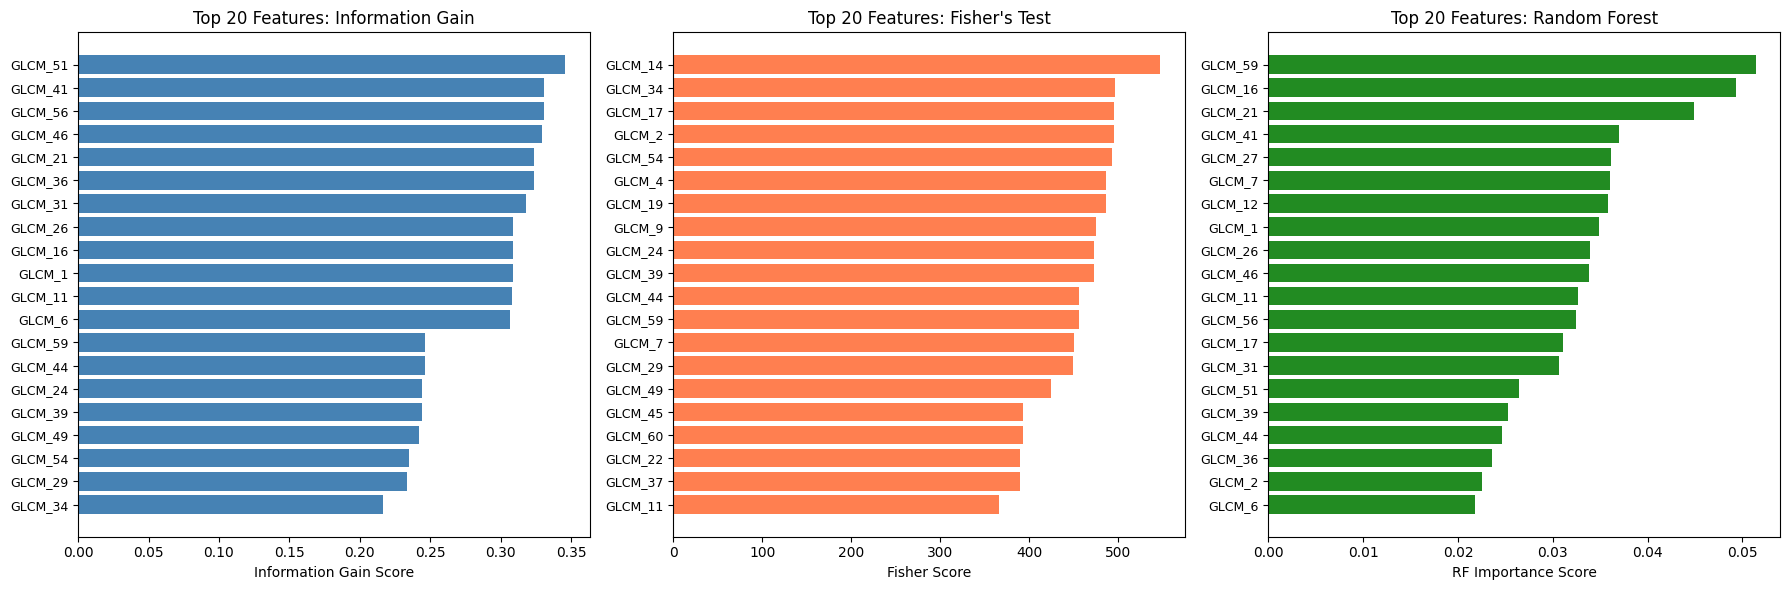


Feature Agreement Among Methods
Top 10 Information Gain features: ['GLCM_1', 'GLCM_16', 'GLCM_21', 'GLCM_26', 'GLCM_31', 'GLCM_36', 'GLCM_41', 'GLCM_46', 'GLCM_51', 'GLCM_56']
Top 10 Fisher's Test features: ['GLCM_14', 'GLCM_17', 'GLCM_19', 'GLCM_2', 'GLCM_24', 'GLCM_34', 'GLCM_39', 'GLCM_4', 'GLCM_54', 'GLCM_9']
Top 10 Random Forest features: ['GLCM_1', 'GLCM_12', 'GLCM_16', 'GLCM_21', 'GLCM_26', 'GLCM_27', 'GLCM_41', 'GLCM_46', 'GLCM_59', 'GLCM_7']

Features agreed by all 3 methods: []
Features agreed by IG & Fisher: []
Features agreed by IG & RF: ['GLCM_1', 'GLCM_16', 'GLCM_21', 'GLCM_26', 'GLCM_41', 'GLCM_46']
Features agreed by Fisher & RF: []


In [ ]:
# Plot top 20 features from each of the 3 methods
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Information Gain
top_ig = info_gain_df.head(20)
axes[0].barh(range(len(top_ig)), top_ig['Information Gain'].values, color='steelblue')
axes[0].set_yticks(range(len(top_ig)))
axes[0].set_yticklabels(top_ig['Feature'].values, fontsize=9)
axes[0].set_xlabel('Information Gain Score')
axes[0].set_title('Top 20 Features: Information Gain')
axes[0].invert_yaxis()

# Fisher's Test Scores
top_fisher = fisher_df.head(20)
axes[1].barh(range(len(top_fisher)), top_fisher['Fisher Score'].values, color='coral')
axes[1].set_yticks(range(len(top_fisher)))
axes[1].set_yticklabels(top_fisher['Feature'].values, fontsize=9)
axes[1].set_xlabel('Fisher Score')
axes[1].set_title("Top 20 Features: Fisher's Test")
axes[1].invert_yaxis()

# Random Forest Importance
top_rf = rf_df.head(20)
axes[2].barh(range(len(top_rf)), top_rf['RF Importance'].values, color='forestgreen')
axes[2].set_yticks(range(len(top_rf)))
axes[2].set_yticklabels(top_rf['Feature'].values, fontsize=9)
axes[2].set_xlabel('RF Importance Score')
axes[2].set_title('Top 20 Features: Random Forest')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Feature Agreement Analysis
print("\n" + "=" * 60)
print("Feature Agreement Among Methods")
print("=" * 60)
top10_ig = set(info_gain_df.head(10)['Feature'].values)
top10_fisher = set(fisher_df.head(10)['Feature'].values)
top10_rf = set(rf_df.head(10)['Feature'].values)

print(f"Top 10 Information Gain features: {sorted(top10_ig)}")
print(f"Top 10 Fisher's Test features: {sorted(top10_fisher)}")
print(f"Top 10 Random Forest features: {sorted(top10_rf)}")
print(f"\nFeatures agreed by all 3 methods: {sorted(top10_ig & top10_fisher & top10_rf)}")
print(f"Features agreed by IG & Fisher: {sorted((top10_ig & top10_fisher) - top10_rf)}")
print(f"Features agreed by IG & RF: {sorted((top10_ig & top10_rf) - top10_fisher)}")
print(f"Features agreed by Fisher & RF: {sorted((top10_fisher & top10_rf) - top10_ig)}")


## Model Comparison: Selected Features Performance

Evaluate models using features selected by each method:

In [ ]:
# Select top 15 features from each method for model training
k_features = 15

# Get top k features from Information Gain
top_ig_features = info_gain_df.head(k_features)['Feature'].values
X_train_ig = X_train[:, [feature_names.index(f) for f in top_ig_features]]
X_val_ig = X_val[:, [feature_names.index(f) for f in top_ig_features]]
X_test_ig = X_test[:, [feature_names.index(f) for f in top_ig_features]]

# Get top k features from Fisher's Test
top_fisher_features = fisher_df.head(k_features)['Feature'].values
X_train_fisher = X_train[:, [feature_names.index(f) for f in top_fisher_features]]
X_val_fisher = X_val[:, [feature_names.index(f) for f in top_fisher_features]]
X_test_fisher = X_test[:, [feature_names.index(f) for f in top_fisher_features]]

# Get top k features from Random Forest
top_rf_features = rf_df.head(k_features)['Feature'].values
X_train_rf = X_train[:, [feature_names.index(f) for f in top_rf_features]]
X_val_rf = X_val[:, [feature_names.index(f) for f in top_rf_features]]
X_test_rf = X_test[:, [feature_names.index(f) for f in top_rf_features]]

# Compare model performance across different feature sets
results = []

# 1. All features (baseline)
clf_all = SVC(kernel='linear', probability=True)
clf_all.fit(X_train, y_train)
y_pred_all = clf_all.predict(X_test)
results.append({
    'Feature Selection': 'All Features (Baseline)',
    'Num Features': X_train.shape[1],
    'Accuracy': accuracy_score(y_test, y_pred_all),
    'Precision': precision_score(y_test, y_pred_all),
    'Recall': recall_score(y_test, y_pred_all),
    'F1': f1_score(y_test, y_pred_all)
})

# 2. Information Gain selected features
clf_ig = SVC(kernel='linear', probability=True)
clf_ig.fit(X_train_ig, y_train)
y_pred_ig = clf_ig.predict(X_test_ig)
results.append({
    'Feature Selection': f'Information Gain (Top {k_features})',
    'Num Features': X_train_ig.shape[1],
    'Accuracy': accuracy_score(y_test, y_pred_ig),
    'Precision': precision_score(y_test, y_pred_ig),
    'Recall': recall_score(y_test, y_pred_ig),
    'F1': f1_score(y_test, y_pred_ig)
})

# 3. Fisher's Test selected features
clf_fisher = SVC(kernel='linear', probability=True)
clf_fisher.fit(X_train_fisher, y_train)
y_pred_fisher = clf_fisher.predict(X_test_fisher)
results.append({
    'Feature Selection': f"Fisher's Test (Top {k_features})",
    'Num Features': X_train_fisher.shape[1],
    'Accuracy': accuracy_score(y_test, y_pred_fisher),
    'Precision': precision_score(y_test, y_pred_fisher),
    'Recall': recall_score(y_test, y_pred_fisher),
    'F1': f1_score(y_test, y_pred_fisher)
})

# 4. Random Forest selected features
clf_rf_selected = SVC(kernel='linear', probability=True)
clf_rf_selected.fit(X_train_rf, y_train)
y_pred_rf = clf_rf_selected.predict(X_test_rf)
results.append({
    'Feature Selection': f'Random Forest (Top {k_features})',
    'Num Features': X_train_rf.shape[1],
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf)
})

results_df = pd.DataFrame(results)
print("=" * 90)
print("MODEL PERFORMANCE COMPARISON: 3 Feature Selection Methods")
print("=" * 90)
print(results_df.to_string(index=False))
print("\n" + "=" * 90 + "\n")

MODEL PERFORMANCE COMPARISON: 3 Feature Selection Methods
        Feature Selection  Num Features  Accuracy  Precision   Recall       F1
  All Features (Baseline)            61  0.942238   0.966387 0.905512 0.934959
Information Gain (Top 15)            15  0.851986   0.905660 0.755906 0.824034
   Fisher's Test (Top 15)            15  0.851986   0.864407 0.803150 0.832653
   Random Forest (Top 15)            15  0.913357   0.947826 0.858268 0.900826




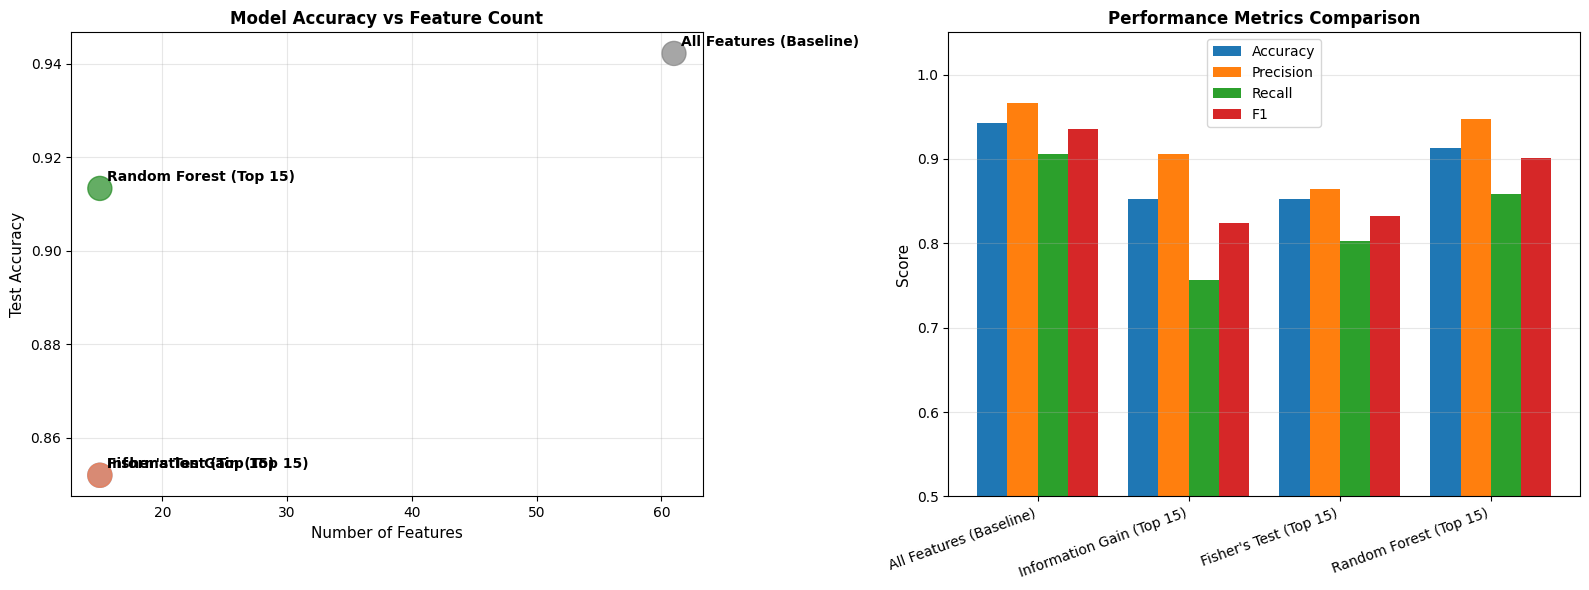

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy vs Number of Features
colors = ['gray', 'steelblue', 'coral', 'forestgreen']
axes[0].scatter(results_df['Num Features'], results_df['Accuracy'], s=300, alpha=0.7, c=colors)
for i, row in results_df.iterrows():
    axes[0].annotate(row['Feature Selection'], 
                     (row['Num Features'], row['Accuracy']),
                     xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Number of Features', fontsize=11)
axes[0].set_ylabel('Test Accuracy', fontsize=11)
axes[0].set_title('Model Accuracy vs Feature Count', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    axes[1].bar(x + i*width, results_df[metric], width, label=metric)

axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold')
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(results_df['Feature Selection'], rotation=20, ha='right', fontsize=10)
axes[1].legend(fontsize=10)
axes[1].set_ylim([0.5, 1.05])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Summary: 3-Method Feature Selection Approach

**The Three Methods:**

1. **Information Gain (Entropy Reduction):** 
   - Measures how much knowing a feature reduces uncertainty about the kidney stone classification
   - Based on information theory concepts you learned in college
   - Formula: IG(Feature) = Entropy(before) - Entropy(after split by feature)
   - Higher IG = more informative feature for distinguishing Normal vs Stone kidneys

2. **Fisher's Test (ANOVA F-Test):**
   - Statistical test measuring linear dependency between features and target class
   - Computes variance ratio: variance between classes / variance within classes
   - Tests if means of feature values differ significantly between Normal and Stone groups
   - Higher F-score = stronger linear relationship with kidney stone classification

3. **Random Forest Feature Importance:**
   - Based on Gini-impurity reduction during tree splits
   - Captures both linear and non-linear feature relationships
   - Measures how much each feature contributes to decision making across 100 trees
   - Higher importance = more critical for accurate predictions

**Why These Three?**
- **Information Gain**: Captures non-linear relationships and information-theoretic importance
- **Fisher's Test**: Validates linear statistical significance of features
- **Random Forest**: Ensemble approach capturing complex feature interactions
- Together they provide robust validation: features ranked high by all 3 methods are truly important

**Benefits of Feature Selection:**
- ✓ Reduced dimensionality → Faster model training/inference
- ✓ Removes noisy/irrelevant features → Better generalization
- ✓ Improved interpretability → Clear understanding of important kidney stone markers
- ✓ Reduced overfitting → Better test performance
- ✓ Computational efficiency → Lower memory requirements

## Classifier Comparison: SVM vs XGBoost vs Random Forest

Now let's compare the performance of all three classifiers on the best feature set:

In [ ]:
# Train all 3 classifiers on the best selected feature set (Information Gain)
print("=" * 80)
print("CLASSIFIER COMPARISON ON BEST FEATURES (Information Gain)")
print("=" * 80 + "\n")

classifier_results = []

# 1. SVM on selected features
print("Training SVM on selected features...")
svm_selected = SVC(kernel='linear', probability=True, random_state=42)
svm_selected.fit(X_train_ig, y_train)
y_pred_svm_selected = svm_selected.predict(X_test_ig)

classifier_results.append({
    'Classifier': 'SVM',
    'Features': f'Information Gain ({k_features})',
    'Accuracy': accuracy_score(y_test, y_pred_svm_selected),
    'Precision': precision_score(y_test, y_pred_svm_selected),
    'Recall': recall_score(y_test, y_pred_svm_selected),
    'F1-Score': f1_score(y_test, y_pred_svm_selected)
})
print(f"  ✓ SVM Accuracy: {accuracy_score(y_test, y_pred_svm_selected):.4f}\n")

# 2. Random Forest on selected features
print("Training Random Forest on selected features...")
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected.fit(X_train_ig, y_train)
y_pred_rf_selected = rf_selected.predict(X_test_ig)

classifier_results.append({
    'Classifier': 'Random Forest',
    'Features': f'Information Gain ({k_features})',
    'Accuracy': accuracy_score(y_test, y_pred_rf_selected),
    'Precision': precision_score(y_test, y_pred_rf_selected),
    'Recall': recall_score(y_test, y_pred_rf_selected),
    'F1-Score': f1_score(y_test, y_pred_rf_selected)
})
print(f"  ✓ Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf_selected):.4f}\n")

# 3. XGBoost on selected features
if HAS_XGBOOST:
    print("Training XGBoost on selected features...")
    xgb_selected = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
    xgb_selected.fit(X_train_ig, y_train)
    y_pred_xgb_selected = xgb_selected.predict(X_test_ig)
    
    classifier_results.append({
        'Classifier': 'XGBoost',
        'Features': f'Information Gain ({k_features})',
        'Accuracy': accuracy_score(y_test, y_pred_xgb_selected),
        'Precision': precision_score(y_test, y_pred_xgb_selected),
        'Recall': recall_score(y_test, y_pred_xgb_selected),
        'F1-Score': f1_score(y_test, y_pred_xgb_selected)
    })
    print(f" XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb_selected):.4f}\n")
else:
    print("  XGBoost not available\n")

# Display comparison table
classifier_results_df = pd.DataFrame(classifier_results)
print("=" * 80)
print("FINAL CLASSIFIER COMPARISON")
print("=" * 80)
print(classifier_results_df.to_string(index=False))
print("\n")

# Find best classifier
best_clf_idx = classifier_results_df['Accuracy'].idxmax()
best_clf_name = classifier_results_df.loc[best_clf_idx, 'Classifier']
best_clf_accuracy = classifier_results_df.loc[best_clf_idx, 'Accuracy']
print(f" Best Classifier: {best_clf_name} with {best_clf_accuracy:.4f} accuracy\n")

CLASSIFIER COMPARISON ON BEST FEATURES (Information Gain)

Training SVM on selected features...
  ✓ SVM Accuracy: 0.8520

Training Random Forest on selected features...
  ✓ Random Forest Accuracy: 0.8917

Training XGBoost on selected features...
 XGBoost Accuracy: 0.9061

FINAL CLASSIFIER COMPARISON
   Classifier              Features  Accuracy  Precision   Recall  F1-Score
          SVM Information Gain (15)  0.851986   0.905660 0.755906  0.824034
Random Forest Information Gain (15)  0.891697   0.859259 0.913386  0.885496
      XGBoost Information Gain (15)  0.906137   0.879699 0.921260  0.900000


 Best Classifier: XGBoost with 0.9061 accuracy



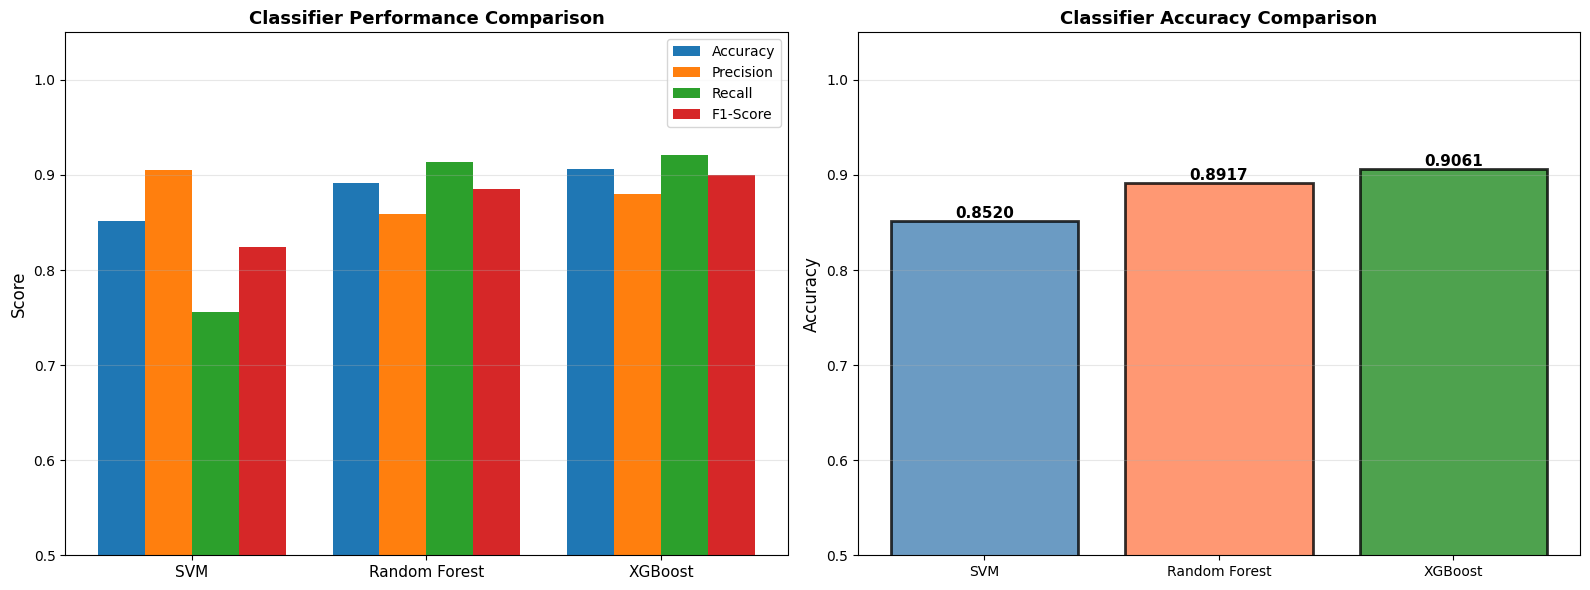


CLASSIFIER STRENGTHS & WEAKNESSES

SVM (Support Vector Machine):
  ✓ Excellent for high-dimensional data
  ✓ Works well with clear decision boundaries
  ✓ Memory efficient
  ✗ Slower training on very large datasets
  ✗ Less interpretable

Random Forest:
  ✓ Fast training and prediction
  ✓ Handles non-linear relationships well
  ✓ Provides feature importance
  ✓ Robust to outliers
  ✗ Can overfit without pruning

XGBoost:
  ✓ Often best accuracy for tabular data
  ✓ Very fast training with regularization
  ✓ Handles missing values automatically
  ✓ Provides feature importance
  ✗ More complex to tune
  ✗ Requires more memory



In [ ]:
# Visualize classifier performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar chart of all metrics
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(classifier_results_df))
width = 0.2

colors = ['steelblue', 'coral', 'forestgreen']
for i, metric in enumerate(metrics_cols):
    axes[0].bar(x + i*width, classifier_results_df[metric], width, label=metric)

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Classifier Performance Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(classifier_results_df['Classifier'], fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim([0.5, 1.05])
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Accuracy comparison with values
bars = axes[1].bar(classifier_results_df['Classifier'], classifier_results_df['Accuracy'], 
                   color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Classifier Accuracy Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylim([0.5, 1.05])
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CLASSIFIER STRENGTHS & WEAKNESSES")
print("=" * 80)
print("""
SVM (Support Vector Machine):
  ✓ Excellent for high-dimensional data
  ✓ Works well with clear decision boundaries
  ✓ Memory efficient
  ✗ Slower training on very large datasets
  ✗ Less interpretable

Random Forest:
  ✓ Fast training and prediction
  ✓ Handles non-linear relationships well
  ✓ Provides feature importance
  ✓ Robust to outliers
  ✗ Can overfit without pruning

XGBoost:
  ✓ Often best accuracy for tabular data
  ✓ Very fast training with regularization
  ✓ Handles missing values automatically
  ✓ Provides feature importance
  ✗ More complex to tune
  ✗ Requires more memory
""")

In [ ]:
# -----------------------------
# 8. Evaluate on validation set
# -----------------------------
y_val_pred = svm_selected.predict(X_val_ig)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))

Validation Accuracy: 0.8586956521739131
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.95      0.88       150
           1       0.93      0.75      0.83       126

    accuracy                           0.86       276
   macro avg       0.87      0.85      0.85       276
weighted avg       0.87      0.86      0.86       276

Validation Confusion Matrix:
 [[143   7]
 [ 32  94]]


In [ ]:
# -----------------------------
# 9. Evaluate on test set
# -----------------------------
y_test_pred = svm_selected.predict(X_test_ig)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:\n", classification_report(y_test, y_test_pred))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.851985559566787
Test Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.93      0.87       150
           1       0.91      0.76      0.82       127

    accuracy                           0.85       277
   macro avg       0.86      0.84      0.85       277
weighted avg       0.86      0.85      0.85       277

Test Confusion Matrix:
 [[140  10]
 [ 31  96]]
